# Predicting the Next 30 Days of Bike Demand

An end-to-end time-series analysis of daily Capital Bikeshare rentals using expanding-window validation, baseline comparison, an untouched final holdout, and empirical forecast intervals.

## tl;dr

- **Selected model:** Holt-Winters, with rolling-validation MAE of **990.878 rentals**.
- **Final 30-day holdout:** MAE **1,480.163**, WAPE **37.466%**, MASE **1.617**.
- **Baseline improvement:** **3.10%**, below the 5% operating threshold.
- **Decision:** **NO-GO** for unattended deployment.
- **Next 30 days:** approximately **67,032 rentals** in total, averaging **2,234.4 per day**.

The forecast is suitable as a planning baseline with a buffer and frequent refreshes—not as an automatic capacity commitment.

## Context & Methods

### Question

Can historical daily demand predict the next 30 days of bike rentals?

### Source

[UCI Bike Sharing dataset](https://archive.ics.uci.edu/dataset/275/bike+sharing+dataset), daily Capital Bikeshare rental counts for 2011–2012, licensed CC BY 4.0.

### Key assumptions

- Forecasts use only information available before each prediction window.
- Future weather is excluded because it is unknown at forecast creation time.
- MAE is the primary planning metric. MAPE is diagnostic only because near-zero holiday demand can distort it.
- The final 30 days remain untouched until after model selection.
- The 95% bands are empirical residual intervals, not full scenario ranges.

## Data

In [1]:
from pathlib import Path
import json
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from statsmodels.tsa.seasonal import STL

from bike_demand.data import load_daily_data
from bike_demand.pipeline import run_pipeline

warnings.filterwarnings('ignore')
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'raw' / 'day.csv'
REPORT_DIR = PROJECT_ROOT / 'reports'

BLUE = '#2463A9'
GOLD = '#C58B24'
CHARCOAL = '#263238'
LIGHT_BLUE = '#B9D5F2'
plt.rcParams.update({'figure.figsize': (12, 4.8), 'axes.grid': True, 'grid.alpha': .25, 'axes.titleweight': 'bold'})

summary = run_pipeline(DATA_PATH, REPORT_DIR)
data = load_daily_data(DATA_PATH)
comparison = pd.read_csv(REPORT_DIR / 'model_comparison.csv')
holdout = pd.read_csv(REPORT_DIR / 'holdout_forecast.csv', parse_dates=['date'])
future = pd.read_csv(REPORT_DIR / 'future_30_day_forecast.csv', parse_dates=['date'])
weekly = pd.read_csv(REPORT_DIR / 'weekly_profile.csv')
summary['dataset']

{'rows': 731,
 'columns': 16,
 'date_start': '2011-01-01',
 'date_end': '2012-12-31',
 'unique_days': 731,
 'missing_values': 0,
 'duplicate_dates': 0,
 'minimum_demand': 22,
 'maximum_demand': 8714,
 'mean_daily_demand': 4504.35,
 'complete_daily_calendar': True,
 'target_reconciles_to_components': True}

The source contains 731 consecutive daily rows with no missing dates, no missing values, and no duplicate dates. Casual plus registered riders reconciles exactly to total demand.

In [2]:
data[['dteday', 'cnt', 'casual', 'registered']].head()

,dteday,cnt,casual,registered
0,2011-01-01,985,331,654
1,2011-01-02,801,131,670
2,2011-01-03,1349,120,1229
3,2011-01-04,1562,108,1454
4,2011-01-05,1600,82,1518


## Results

### 1. Inspect the trend

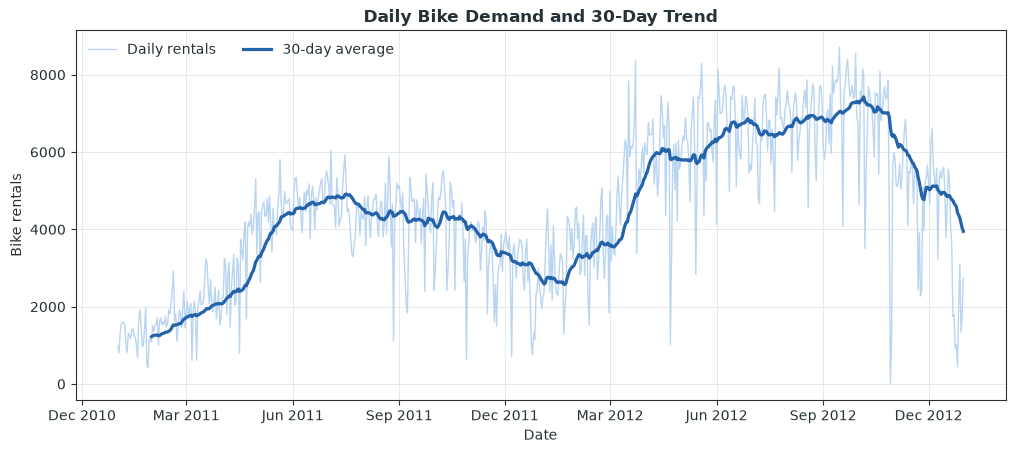

In [3]:
fig, ax = plt.subplots()
ax.plot(data['dteday'], data['cnt'], color=LIGHT_BLUE, linewidth=1, label='Daily rentals')
ax.plot(data['dteday'], data['cnt'].rolling(30).mean(), color=BLUE, linewidth=2.3, label='30-day average')
ax.set(title='Daily Bike Demand and 30-Day Trend', xlabel='Date', ylabel='Bike rentals')
ax.legend(frameon=False, ncol=2)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.show()

The smoothed series rises materially from 2011 into 2012, so assuming a constant level would be inappropriate. The ADF p-value is 0.3427; the level series does not provide evidence of stationarity at the 5% threshold.

### 2. Separate weekly seasonality from trend

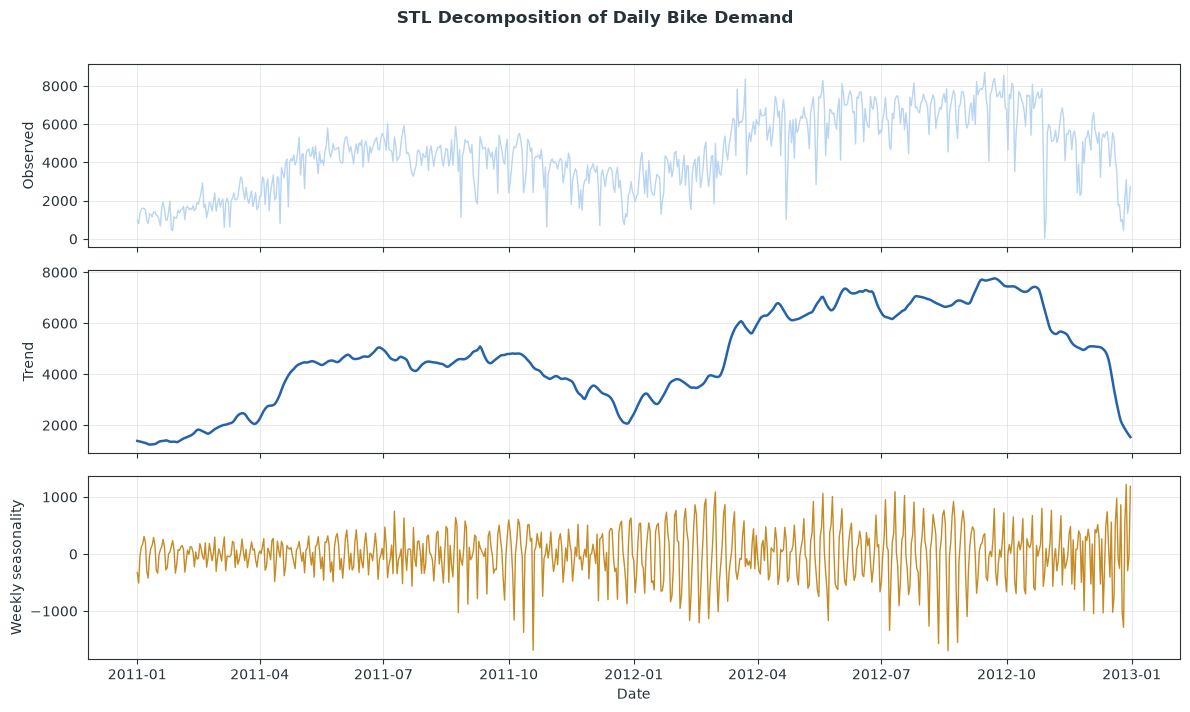

In [4]:
stl = STL(data.set_index('dteday')['cnt'], period=7, robust=True).fit()
fig, axes = plt.subplots(3, 1, figsize=(12, 7), sharex=True)
axes[0].plot(stl.observed, color=LIGHT_BLUE, linewidth=1); axes[0].set_ylabel('Observed')
axes[1].plot(stl.trend, color=BLUE, linewidth=1.8); axes[1].set_ylabel('Trend')
axes[2].plot(stl.seasonal, color=GOLD, linewidth=1); axes[2].set_ylabel('Weekly seasonality'); axes[2].set_xlabel('Date')
fig.suptitle('STL Decomposition of Daily Bike Demand', fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

Weekly structure is visible, but the residual variation remains large relative to the weekly component. This motivates benchmarking every statistical model against a simple seven-day repeat.

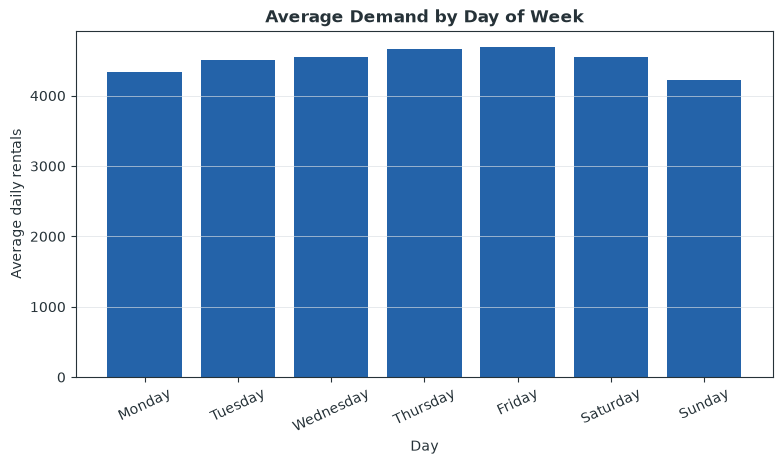

,weekday_name,mean_demand,median_demand
0,Monday,4338.12,4359.0
1,Tuesday,4510.66,4576.5
2,Wednesday,4548.54,4642.5
3,Thursday,4667.26,4721.0
4,Friday,4690.29,4601.5
5,Saturday,4550.54,4521.0
6,Sunday,4228.83,4334.0


In [5]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(weekly['weekday_name'], weekly['mean_demand'], color=BLUE)
ax.set(title='Average Demand by Day of Week', xlabel='Day', ylabel='Average daily rentals')
ax.tick_params(axis='x', rotation=25)
ax.grid(axis='x', visible=False)
plt.show()
weekly

### 3. Compare forecasting approaches with rolling validation

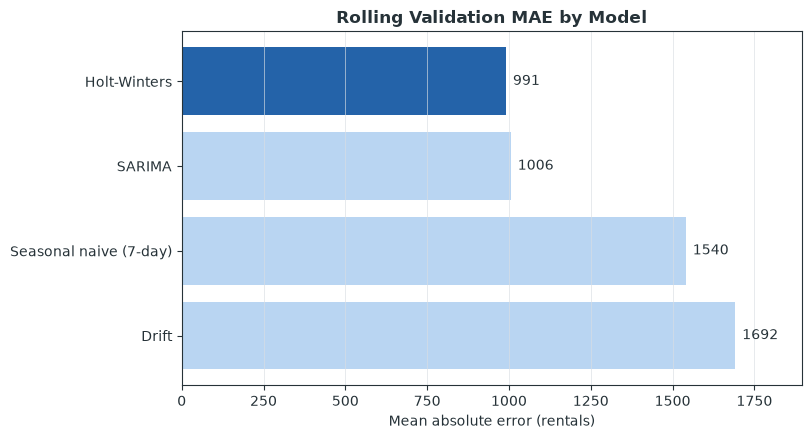

,model,model_label,cv_mae,cv_rmse,cv_mape_pct,cv_mase
0,holt_winters,Holt-Winters,990.878,1428.069,368.478,1.147
1,sarima,SARIMA,1005.512,1505.883,396.052,1.162
2,seasonal_naive,Seasonal naive (7-day),1540.356,2103.959,373.107,1.769
3,drift,Drift,1691.586,1934.421,272.115,1.961


In [6]:
ranked = comparison.sort_values('cv_mae')
fig, ax = plt.subplots(figsize=(8, 4.6))
bars = ax.barh(ranked['model_label'], ranked['cv_mae'], color=[BLUE] + [LIGHT_BLUE] * (len(ranked) - 1))
ax.invert_yaxis(); ax.grid(axis='y', visible=False)
ax.set(title='Rolling Validation MAE by Model', xlabel='Mean absolute error (rentals)', ylabel='')
ax.bar_label(bars, fmt='%.0f', padding=5)
ax.set_xlim(0, ranked['cv_mae'].max() * 1.12)
plt.show()
comparison

Holt-Winters has the lowest average rolling-validation MAE. Model selection uses only the three validation windows; the final 30-day holdout remains untouched.

### 4. Test the selected model on the untouched final month

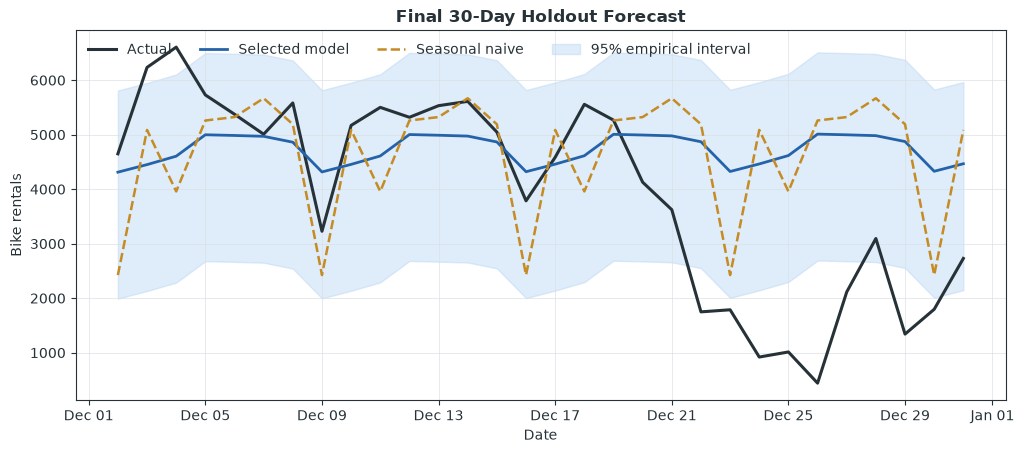

In [7]:
fig, ax = plt.subplots()
ax.plot(holdout['date'], holdout['actual'], color=CHARCOAL, linewidth=2.2, label='Actual')
ax.plot(holdout['date'], holdout['forecast'], color=BLUE, linewidth=2, label='Selected model')
ax.plot(holdout['date'], holdout['seasonal_naive'], color=GOLD, linestyle='--', linewidth=1.8, label='Seasonal naive')
ax.fill_between(holdout['date'], holdout['lower_95'], holdout['upper_95'], color=LIGHT_BLUE, alpha=.45, label='95% empirical interval')
ax.set(title='Final 30-Day Holdout Forecast', xlabel='Date', ylabel='Bike rentals')
ax.legend(frameon=False, ncol=4, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.show()

In [8]:
pd.DataFrame({
    'Selected model': summary['holdout_selected_model'],
    'Seasonal naive': summary['holdout_seasonal_naive'],
}).T[['mae', 'rmse', 'wape_pct', 'mase', 'bias']]

,mae,rmse,wape_pct,mase,bias
Selected model,1480.163,1932.709,37.466,1.617,772.601
Seasonal naive,1527.567,2054.837,38.665,1.669,687.900


The selected model improves MAE by only **3.10%** and overforecasts by **772.6 rentals per day on average**. It therefore receives a **NO-GO** decision.

### 5. Refit and forecast the next 30 days

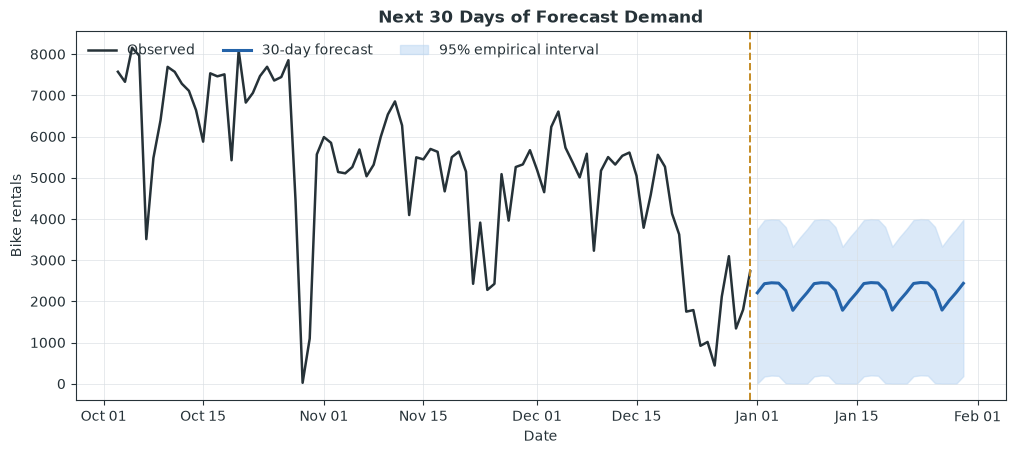

In [9]:
recent = data.tail(90)
fig, ax = plt.subplots()
ax.plot(recent['dteday'], recent['cnt'], color=CHARCOAL, linewidth=1.8, label='Observed')
ax.plot(future['date'], future['forecast'], color=BLUE, linewidth=2.2, label='30-day forecast')
ax.fill_between(future['date'], future['lower_95'], future['upper_95'], color=LIGHT_BLUE, alpha=.5, label='95% empirical interval')
ax.axvline(data['dteday'].max(), color=GOLD, linestyle='--', linewidth=1.4)
ax.set(title='Next 30 Days of Forecast Demand', xlabel='Date', ylabel='Bike rentals')
ax.legend(frameon=False, ncol=3, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.show()

In [10]:
future.assign(
    forecast=future['forecast'].round(0).astype(int),
    lower_95=future['lower_95'].round(0).astype(int),
    upper_95=future['upper_95'].round(0).astype(int),
).head(10)

,date,forecast,lower_95,upper_95
0,2013-01-01,2206,0,3747
1,2013-01-02,2427,176,3968
2,2013-01-03,2450,198,3991
3,2013-01-04,2441,190,3982
4,2013-01-05,2260,9,3801
5,2013-01-06,1781,0,3322
6,2013-01-07,2009,0,3550
7,2013-01-08,2208,0,3749
8,2013-01-09,2429,178,3970
9,2013-01-10,2452,200,3993


## Takeaways

1. **Historical demand contains useful trend and weekly structure**, and Holt-Winters clearly outperforms drift and the weekly baseline during rolling validation.
2. **The final month is harder than the validation average.** Holdout MAE rises to 1,480 rentals and MASE remains above 1.0.
3. **Do not automate capacity from this model yet.** Use the 67,032-rental 30-day forecast as a buffered planning baseline.
4. **Next improvement:** add more years of history plus forecast-time weather, holidays, events, pricing, and system-capacity inputs, then repeat the untouched-holdout gate.

The empirical intervals summarize historical residuals; they are not guarantees and do not capture every structural shock.